In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Load cleaned dataset
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Preview the first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


,state,district,market,commodity,variety,grade,arrival_date,min_price,max_price,modal_price
0,gujarat,amreli,damnagar,bhindi(ladies finger),bhindi,faq,2023-07-27,4100.0,4500.0,4350.0
1,gujarat,amreli,damnagar,brinjal,other,faq,2023-07-27,2200.0,3000.0,2450.0
2,gujarat,amreli,damnagar,cabbage,cabbage,faq,2023-07-27,2350.0,3000.0,2700.0
3,gujarat,amreli,damnagar,cauliflower,cauliflower,faq,2023-07-27,7000.0,7500.0,7250.0
4,gujarat,amreli,damnagar,coriander(leaves),coriander,faq,2023-07-27,8400.0,9000.0,8850.0


/var/folders/cy/8gf3c1f93cqcffq0wpgcw2740000gn/T/ipykernel_55949/4130957531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_commodities.values, y=top_commodities.index, palette='viridis')


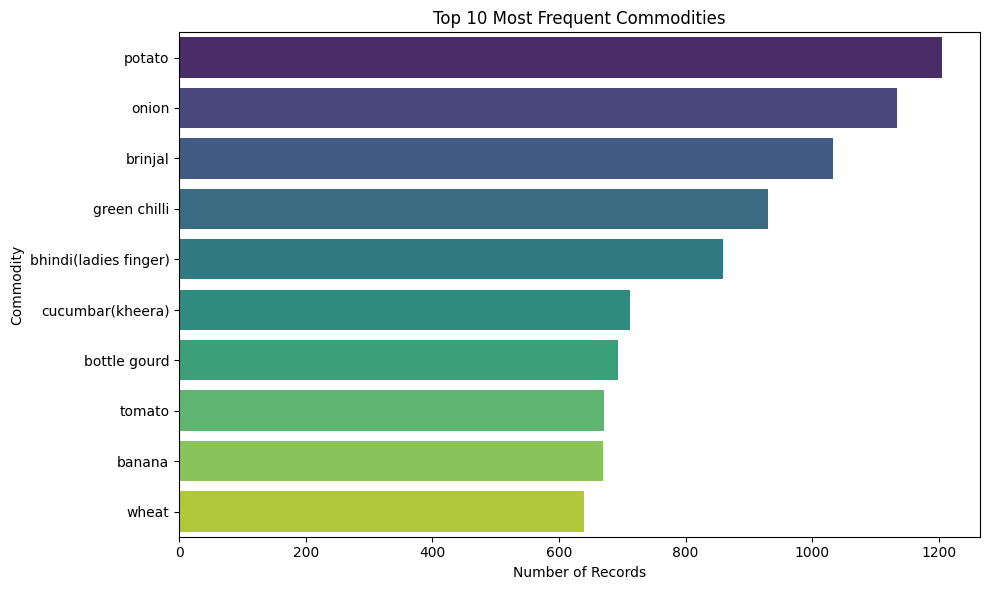

In [2]:
# Count most common commodities
top_commodities = df['commodity'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_commodities.values, y=top_commodities.index, palette='viridis')
plt.title("Top 10 Most Frequent Commodities")
plt.xlabel("Number of Records")
plt.ylabel("Commodity")
plt.tight_layout()
plt.show()

/var/folders/cy/8gf3c1f93cqcffq0wpgcw2740000gn/T/ipykernel_55949/2427733055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg_price.values, y=state_avg_price.index, palette='mako')


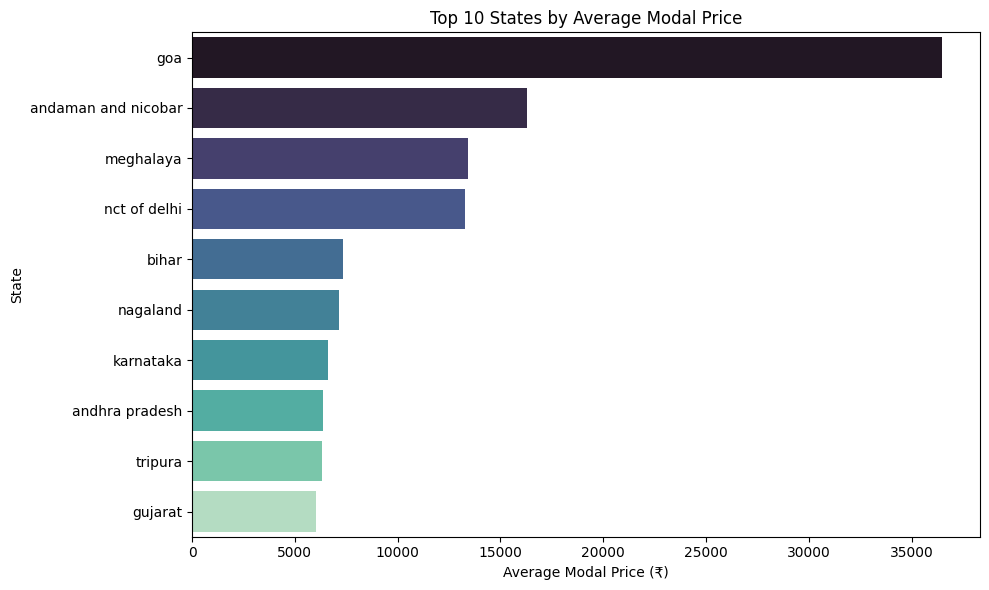

In [3]:
# Group by state and calculate average modal price
state_avg_price = df.groupby('state')['modal_price'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=state_avg_price.values, y=state_avg_price.index, palette='mako')
plt.title("Top 10 States by Average Modal Price")
plt.xlabel("Average Modal Price (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

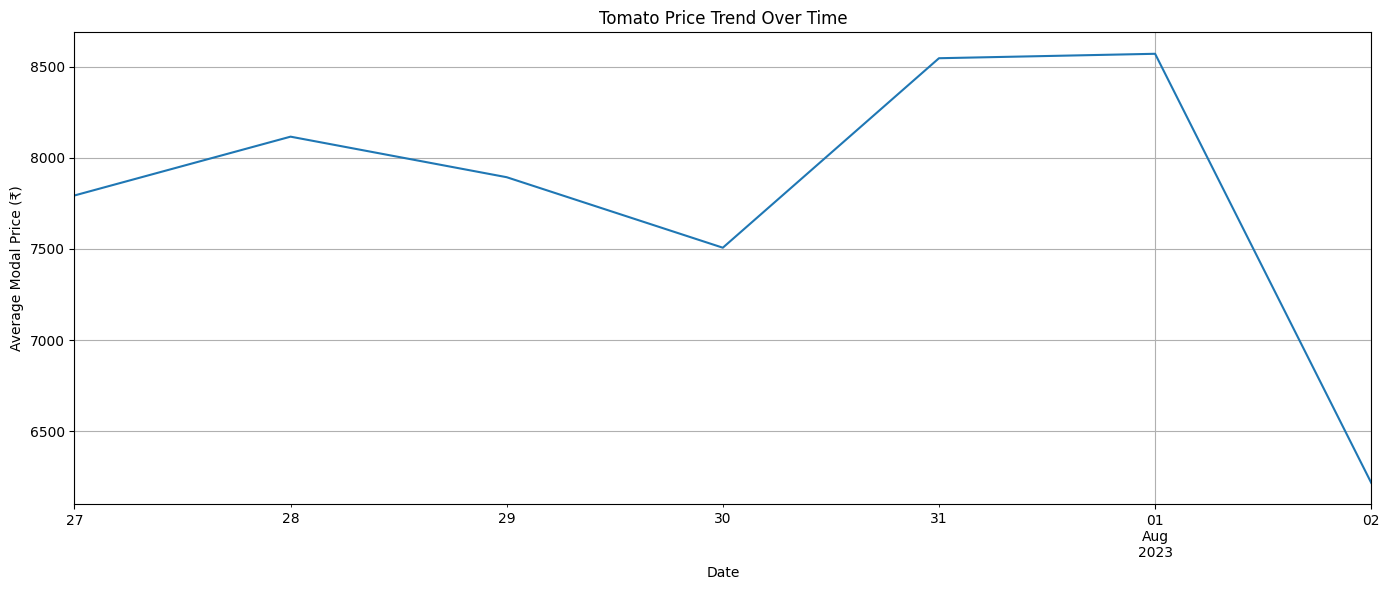

In [4]:
# Convert arrival_date to datetime (if not already done)
df['arrival_date'] = pd.to_datetime(df['arrival_date'], errors='coerce')

# Filter data for Tomato only
tomato_df = df[df['commodity'].str.lower() == 'tomato']

# Group by date and calculate average modal price per day
tomato_trend = tomato_df.groupby('arrival_date')['modal_price'].mean()

# Plot
plt.figure(figsize=(14,6))
tomato_trend.plot()
plt.title("Tomato Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Modal Price (₹)")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/cy/8gf3c1f93cqcffq0wpgcw2740000gn/T/ipykernel_55949/1060128628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='modal_price', y='commodity', palette='coolwarm')


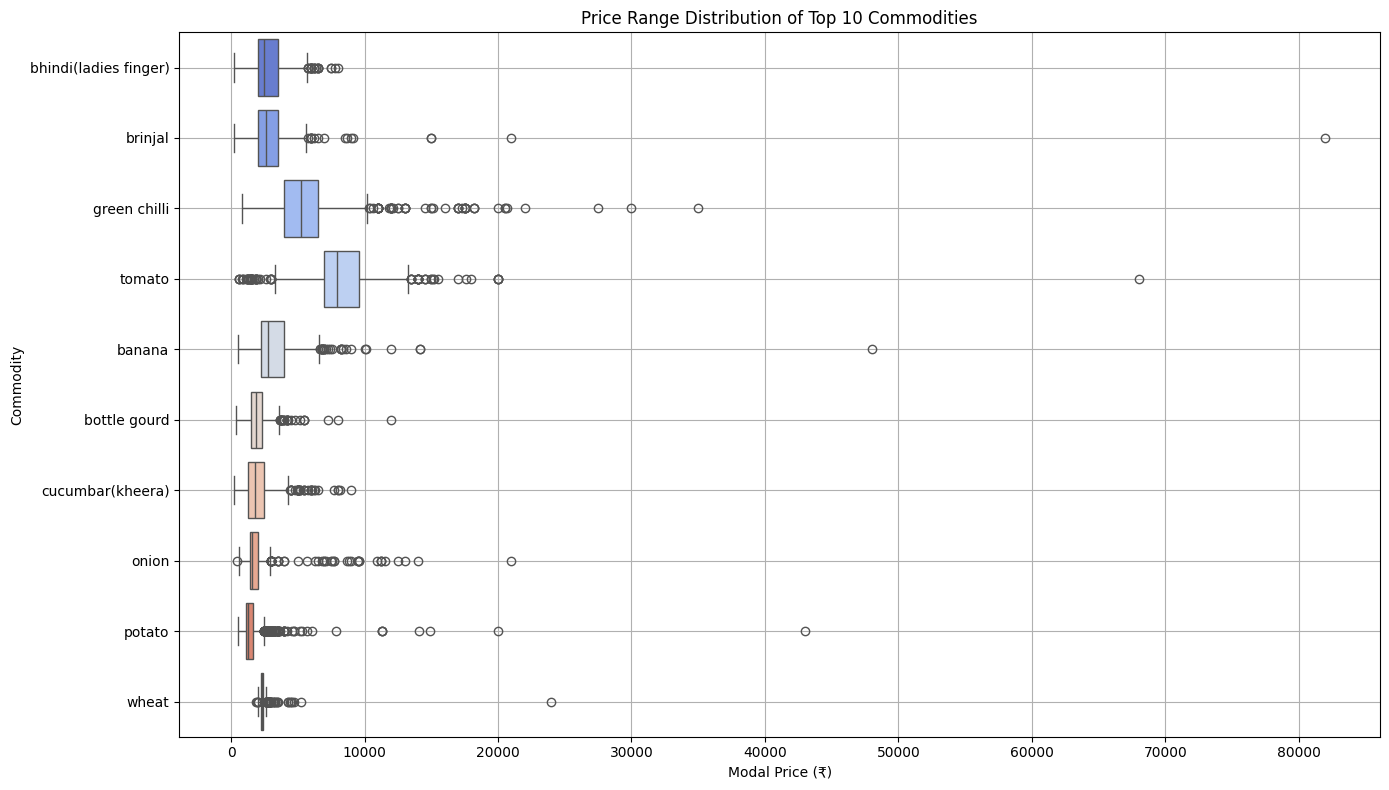

In [5]:
# Select top 10 commodities by frequency
top_commodities = df['commodity'].value_counts().head(10).index.tolist()

# Filter for only those commodities
filtered_df = df[df['commodity'].isin(top_commodities)]

# Plot boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=filtered_df, x='modal_price', y='commodity', palette='coolwarm')
plt.title("Price Range Distribution of Top 10 Commodities")
plt.xlabel("Modal Price (₹)")
plt.ylabel("Commodity")
plt.grid(True)
plt.tight_layout()
plt.show()

## 📊 Summary of Key Insights

1. **Top Commodities by Frequency**  
   Potato, Onion, and Brinjal are the most frequently traded — showing high demand and supply chain relevance.

2. **Top 10 States by Average Modal Price**  
   Goa, Meghalaya, and NCT of Delhi have the highest average modal prices, suggesting premium or urban markets.

3. **Tomato Price Trend Over Time**  
   Tomato prices spiked on August 1, 2023, crossing ₹8,500 — showing high seasonal volatility.

4. **Price Volatility Across Crops**  
   Boxplots revealed crops like Tomato and Bhindi have wide price ranges and outliers, while Wheat and Banana are relatively stable.

> These insights are actionable for agri-delivery startups like DesiCultor to improve sourcing, delivery timing, and pricing strategies.